In [3]:
import numpy as np  
import pandas as pd  
  
import matplotlib.pyplot as plt  
import plotly.express as px  
from plotly.offline import init_notebook_mode, iplot  
init_notebook_mode(connected=True)  
  
from sklearn.decomposition import PCA  
  
from sklearn. preprocessing import StandardScaler  
from sklearn.model_selection import train_test_split  
from sklearn.model_selection import cross_val_score  
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  
  
from sklearn.metrics import accuracy_score  
from sklearn.metrics import precision_score, recall_score, f1_score  
  
import pickle  

In [4]:
dataframe = pd.read_csv('collegePlace.csv')

In [5]:
dataframe.shape  
dataframe.head()  
 

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [6]:
dataframe.sample(4) 

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
1759,22,Male,Civil,0,5,1,0,0
1507,24,Male,Computer Science,0,8,0,0,1
2587,21,Male,Electronics And Communication,0,7,0,0,1
1177,21,Male,Information Technology,1,9,0,0,1


In [7]:
dataframe.dtypes
dataframe.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2966 non-null   int64 
 1   Gender             2966 non-null   object
 2   Stream             2966 non-null   object
 3   Internships        2966 non-null   int64 
 4   CGPA               2966 non-null   int64 
 5   Hostel             2966 non-null   int64 
 6   HistoryOfBacklogs  2966 non-null   int64 
 7   PlacedOrNot        2966 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 185.5+ KB


In [8]:
dataframe.describe()  

,Age,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
count,2966.000000,2966.000000,2966.000000,2966.000000,2966.000000,2966.000000
mean,21.485840,0.703641,7.073837,0.269049,0.192178,0.552596
std,1.324933,0.740197,0.967748,0.443540,0.394079,0.497310
min,19.000000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,6.000000,0.000000,0.000000,0.000000
50%,21.000000,1.000000,7.000000,0.000000,0.000000,1.000000
75%,22.000000,1.000000,8.000000,1.000000,0.000000,1.000000
max,30.000000,3.000000,9.000000,1.000000,1.000000,1.000000


In [9]:
numeric_df = dataframe.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
placed_corr = corr_matrix['PlacedOrNot']
  

In [10]:
dataframe.isnull().sum()  

Age                  0
Gender               0
Stream               0
Internships          0
CGPA                 0
Hostel               0
HistoryOfBacklogs    0
PlacedOrNot          0
dtype: int64

In [11]:
print(dataframe.duplicated().sum())  
dataframe.drop_duplicates(inplace=True)  

1829


In [12]:
print(dataframe.duplicated().sum())  

0


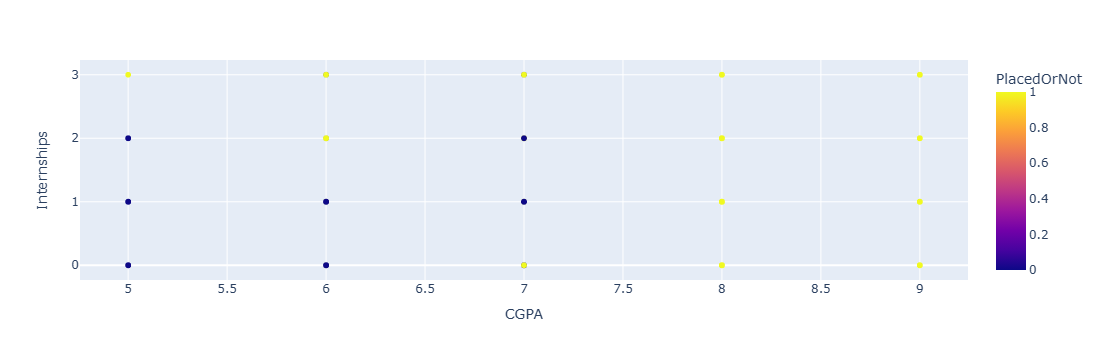

In [13]:
figure = px.scatter(dataframe, x="CGPA", y="Internships", color="PlacedOrNot",  
                 hover_data=['CGPA'])  
figure.show()  

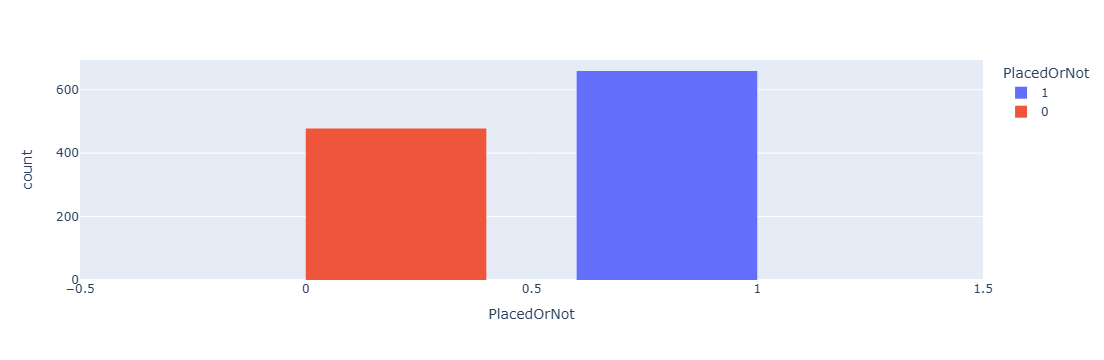

In [14]:
px.histogram(dataframe, x='PlacedOrNot', color='PlacedOrNot', barmode='group')  

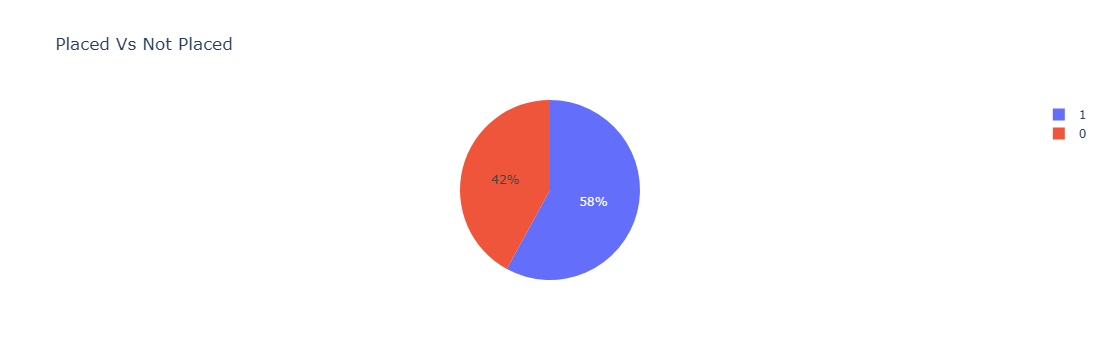

In [15]:
figure = px.pie(dataframe, values=dataframe['PlacedOrNot'].value_counts().values, names=dataframe['PlacedOrNot'].value_counts().index, title='Placed Vs Not Placed')  
figure.show()  

In [16]:
print("Max Age of Placed Person: ",dataframe[(dataframe['Age'] == dataframe['Age'].max()) & (dataframe['PlacedOrNot']==1)]['Age'].values[0])  
print("Min Age of Placed Person: ",dataframe[(dataframe['Age'] == dataframe['Age'].min()) & (dataframe['PlacedOrNot']==1)]['Age'].values[0])  

Max Age of Placed Person:  30
Min Age of Placed Person:  19


In [17]:
print("Max Internships Done by the Placed Student: ",dataframe[(dataframe['Internships'] == dataframe['Internships'].max()) & (dataframe['PlacedOrNot']==1)]['Internships'].values[0])  
print("No of students who did max Internships and are placed: ",dataframe[(dataframe['Internships'] == dataframe['Internships'].max()) & (dataframe['PlacedOrNot']==1)]['Internships'].value_counts().values[0])  
  
print("Min Internships Done by the Placed Person: ",dataframe[(dataframe['Internships'] == dataframe['Internships'].min()) & (dataframe['PlacedOrNot']==1)]['Internships'].values[0])  
print("No of students who did min Internships and are placed: ",dataframe[(dataframe['Internships'] == dataframe['Internships'].min()) & (dataframe['PlacedOrNot']==1)]['Internships'].value_counts().values[0])  

Max Internships Done by the Placed Student:  3
No of students who did max Internships and are placed:  35
Min Internships Done by the Placed Person:  0
No of students who did min Internships and are placed:  232


In [18]:
print("Max CGPA of Placed Student: ",dataframe[(dataframe['CGPA'] == dataframe['CGPA'].max()) & (dataframe['PlacedOrNot']==1)]['CGPA'].values[0])  
print("No of students has max CGPA and are placed: ",dataframe[(dataframe['CGPA'] == dataframe['CGPA'].max()) & (dataframe['PlacedOrNot']==1)]['CGPA'].value_counts().values[0])  
  
print("Min CGPA of Placed Person: ",dataframe[(dataframe['CGPA'] == dataframe['CGPA'].min()) & (dataframe['PlacedOrNot']==1)]['CGPA'].values[0])  
print("No of students has min CGPA and are placed: ",dataframe[(dataframe['CGPA'] == dataframe['CGPA'].min()) & (dataframe['PlacedOrNot']==1)]['CGPA'].value_counts().values[0])  

Max CGPA of Placed Student:  9
No of students has max CGPA and are placed:  99
Min CGPA of Placed Person:  5
No of students has min CGPA and are placed:  5


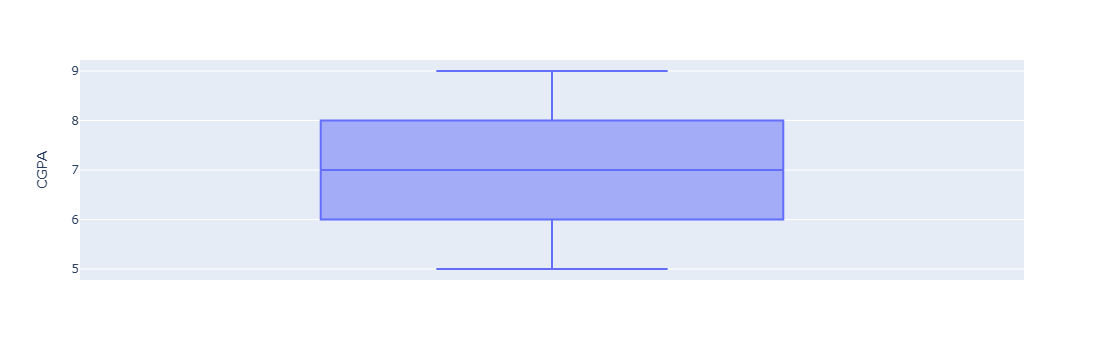

In [19]:
figure = px.box(dataframe, y='CGPA')  
figure.show()  

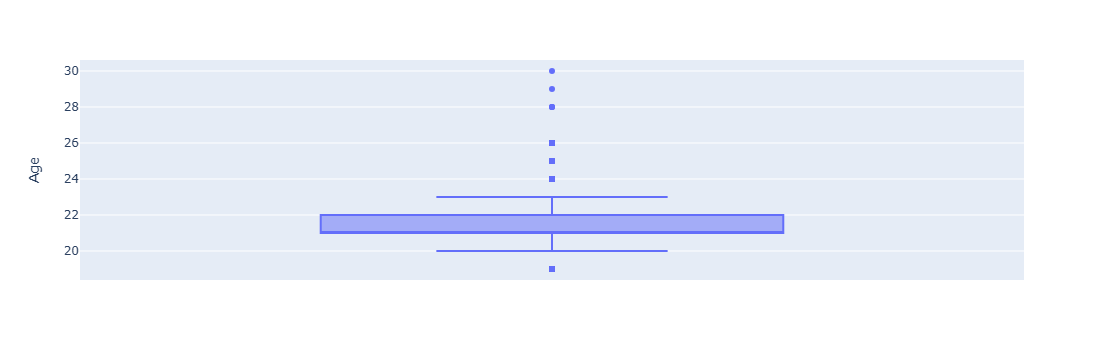

In [20]:
figure = px.box(dataframe, y='Age')  
figure.show()  

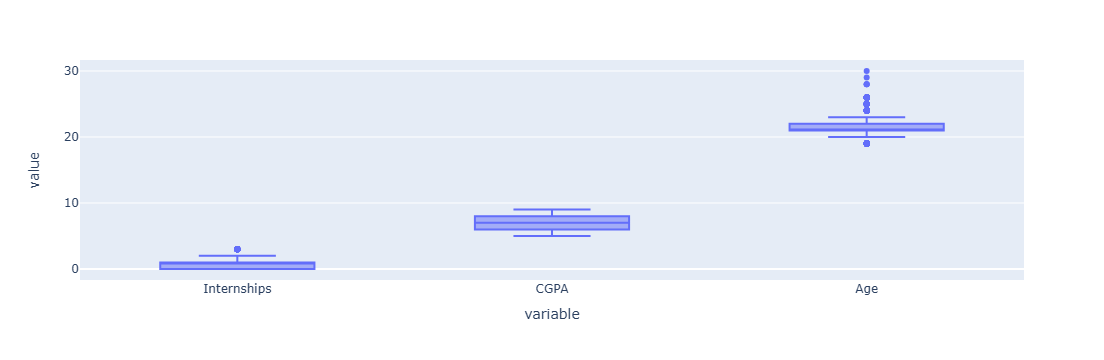

In [21]:
figure = px.box(dataframe, y=['Internships','CGPA', 'Age'])  
figure.show()  

In [22]:
dataframe['Gender'] = dataframe['Gender'].map({'Male': 1, 'Female': 0})  
dataframe['Stream'].unique()  

array(['Electronics And Communication', 'Computer Science',
       'Information Technology', 'Mechanical', 'Electrical', 'Civil'],
      dtype=object)

In [23]:
dataframe['Stream'] = dataframe['Stream'].map({'Electronics And Communication': 1,  
                                 'Computer Science': 2,  
                                'Information Technology': 3,  
                                'Mechanical':4,  
                                'Electrical':5,  
                                'Civil':6})  
dataframe.sample(5)  

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
143,24,1,2,2,5,0,0,1
2104,20,0,2,1,6,1,1,1
2802,22,1,1,0,6,0,1,0
1109,21,1,3,1,9,0,0,1
182,21,1,1,1,6,0,1,0


In [24]:
X = dataframe.iloc[:,0:7]  
y = dataframe.iloc[:,-1]  
X  

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs
0,22,1,1,1,8,1,1
1,21,0,2,0,7,1,1
2,22,0,3,1,6,0,0
3,21,1,3,0,8,0,1
4,22,1,4,0,8,1,0
...,...,...,...,...,...,...,...
2946,23,1,3,1,7,1,1
2952,23,1,4,0,8,1,0
2954,23,0,2,1,8,0,1
2958,23,1,2,0,6,0,1


In [25]:
print(X.shape)  
print(y.shape)  

(1137, 7)
(1137,)


In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33)  
print(X_train.shape)  
print(X_test.shape)  
print(y_train.shape)  
print(y_test.shape)  

(761, 7)
(376, 7)
(761,)
(376,)


In [27]:
scaler = StandardScaler()  
X_train_scale = scaler.fit_transform(X_train)  
X_test_scale = scaler.transform(X_test)  


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Handle NaN values by filling them with the mean of the respective columns
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scale = scaler.fit_transform(X_train)

# Transform the test data
X_test_scale = scaler.transform(X_test)

# Initialize the LogisticRegression classifier
classifier = LogisticRegression()

# Without Scaling
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print("Without Scaling and CV: ", accuracy_score(y_test, y_pred))
scores = cross_val_score(classifier, X_train, y_train, cv=10)
print("Without Scaling and With CV: ", scores.mean())

# With Scaling
classifier.fit(X_train_scale, y_train)
y_pred = classifier.predict(X_test_scale)
print("With Scaling and Without CV: ", accuracy_score(y_test, y_pred))
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)
print("With Scaling and With CV: ", scores.mean())


Without Scaling and CV:  0.7047872340425532
Without Scaling and With CV:  0.7266917293233084
With Scaling and Without CV:  0.7074468085106383
With Scaling and With CV:  0.7293233082706767


In [29]:
from sklearn.tree import DecisionTreeClassifier  
classifier = DecisionTreeClassifier(random_state=0)  
  
#without scaling  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.7207446808510638
Without Scaling and With CV:  0.7358851674641149
With Scaling and Without CV:  0.7180851063829787
With Scaling and With CV:  0.7358851674641149


In [30]:
from sklearn.ensemble import RandomForestClassifier  
  
classifier = RandomForestClassifier(max_depth=10, random_state=0)  
  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.7712765957446809
Without Scaling and With CV:  0.7793403964456596
With Scaling and Without CV:  0.7712765957446809
With Scaling and With CV:  0.7793403964456596


In [31]:
from sklearn.svm import SVC  
  
svc = SVC()  
parameters = {'kernel':('linear', 'rbf'), 'C':[1, 10]}  
classifier = GridSearchCV(svc, parameters)  
  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.723404255319149
Without Scaling and With CV:  0.7516746411483253
With Scaling and Without CV:  0.7606382978723404
With Scaling and With CV:  0.785868079289132


In [32]:
from sklearn.svm import NuSVC  
classifier = NuSVC()  
  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.7579787234042553
Without Scaling and With CV:  0.7713943950786056
With Scaling and Without CV:  0.7579787234042553
With Scaling and With CV:  0.7819207108680792


In [33]:
from sklearn.naive_bayes import GaussianNB  
classifier = GaussianNB()  
  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.7287234042553191
Without Scaling and With CV:  0.7661483253588516
With Scaling and Without CV:  0.7287234042553191
With Scaling and With CV:  0.7661483253588516


In [34]:
from sklearn.naive_bayes import MultinomialNB  
classifier = MultinomialNB()  
  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.6117021276595744
Without Scaling and With CV:  0.6372863978127137


In [35]:
from sklearn.naive_bayes import BernoulliNB  
classifier = BernoulliNB()  
  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.5425531914893617
Without Scaling and With CV:  0.5860731373889267
With Scaling and Without CV:  0.7659574468085106
With Scaling and With CV:  0.7609193438140807


In [36]:
from sklearn.naive_bayes import CategoricalNB  
classifier = CategoricalNB()  
  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  


Without Scaling and CV:  0.7952127659574468


In [37]:
from sklearn.neighbors import KNeighborsClassifier  
classifier = KNeighborsClassifier(n_neighbors=3)  
  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.699468085106383
Without Scaling and With CV:  0.7464114832535884
With Scaling and Without CV:  0.6888297872340425
With Scaling and With CV:  0.7215311004784689


In [38]:
from sklearn.linear_model import SGDClassifier  
classifier = SGDClassifier(max_iter=1000, tol=1e-3)  
  
# Without Scaling  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.6941489361702128
Without Scaling and With CV:  0.6872863978127135
With Scaling and Without CV:  0.7101063829787234
With Scaling and With CV:  0.683321941216678


In [39]:
from sklearn.linear_model import Perceptron  
  
classifier = Perceptron(tol=1e-3, random_state=0)  
# Without Scaling  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.6382978723404256
Without Scaling and With CV:  0.634688995215311
With Scaling and Without CV:  0.625
With Scaling and With CV:  0.6897812713602187


In [40]:
from sklearn.linear_model import LogisticRegressionCV  
classifier = LogisticRegressionCV(cv=5, random_state=0)  
  
# Without Scaling  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without Scaling and CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("Without Scaling and With CV: ",scores.mean())  
  
# With Scaling  
classifier.fit(X_train_scale,y_train)  
y_pred = classifier.predict(X_test_scale)  
print("With Scaling and Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train_scale, y_train, cv=10)  
print("With Scaling and With CV: ",scores.mean())  

Without Scaling and CV:  0.7074468085106383
Without Scaling and With CV:  0.7253759398496241
With Scaling and Without CV:  0.7047872340425532
With Scaling and With CV:  0.7293233082706767


In [41]:
classifier = RandomForestClassifier(max_depth=10, random_state=0)  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("With CV: ",scores.mean())  
print("Precision Score: ", precision_score(y_test, y_pred))  
print("Recall Score: ", recall_score(y_test, y_pred))  
print("F1 Score: ", f1_score(y_test, y_pred))  

Without CV:  0.7712765957446809
With CV:  0.7793403964456596
Precision Score:  0.8432432432432433
Recall Score:  0.7323943661971831
F1 Score:  0.7839195979899497


In [42]:
param_grid = {  
    'bootstrap': [False, True],  
    'max_depth': [5, 8, 10, 20],  
    'max_features': [3, 4, 5, None],  
    'min_samples_split': [2, 10, 12],  
    'n_estimators': [100, 200, 300]  
}  
  
rfclassifier = RandomForestClassifier()  
  
classifier = GridSearchCV(estimator=rfclassifier, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)  
  
classifier.fit(X_train, y_train)  
y_pred = classifier.predict(X_test)  
print("Accuracy: ", accuracy_score(y_test, y_pred))  
print(classifier.best_params_)  
print(classifier.best_estimator_)
 

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Accuracy:  0.8031914893617021
{'bootstrap': True, 'max_depth': 5, 'max_features': 4, 'min_samples_split': 10, 'n_estimators': 300}
RandomForestClassifier(max_depth=5, max_features=4, min_samples_split=10,
                       n_estimators=300)


In [43]:
classifier = RandomForestClassifier(bootstrap=False, max_depth=5,max_features=None,  
                             min_samples_split=2,  
                             n_estimators=100, random_state=0)  
classifier.fit(X_train,y_train)  
y_pred = classifier.predict(X_test)  
print("Without CV: ",accuracy_score(y_test,y_pred))  
scores = cross_val_score(classifier, X_train, y_train, cv=10)  
print("With CV: ",scores.mean())  
print("Precision Score: ", precision_score(y_test, y_pred))  
print("Recall Score: ", recall_score(y_test, y_pred))  
print("F1 Score: ", f1_score(y_test, y_pred))  

Without CV:  0.8085106382978723
With CV:  0.822676008202324
Precision Score:  0.9272727272727272
Recall Score:  0.7183098591549296
F1 Score:  0.8095238095238095
